1. На основе учебного ноутбука проведите финальную подготовку данных. Измените количество сегментирующих классов с `16` на `7`:
  - 0_класс - FLOOR
  - 1_класс - CEILING
  - 2_класс - WALL
  - 3_класс - APERTURE, DOOR, WINDOW
  - 4_класс - COLUMN, RAILINGS, LADDER
  - 5_класс - INVENTORY
  - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Изучите внимательно особенности `U-net`, определите в чем принципиальное отличие  `U-net `  и   `simpleUnet` из учебного ноутбука.

3. Доработайте `simpleUnet` с учетом особенностей `U-net `. Обучите модель на 100 эпохах и визуализируйте результат.

**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

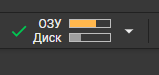

Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [ ]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

import tensorflow as tf
 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:07<00:00, 27.1MB/s]


### Предварительная подготовка данных


In [ ]:
# Глобальные параметры

IMG_WIDTH = 256               # Ширина картинки
IMG_HEIGHT = 192             # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [ ]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.47c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [ ]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.62c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.03c
Количество изображений:  100


## Решение

In [ ]:
# Маппинг 16 исходных классов в 7 новых
# 0=FLOOR, 1=CEILING, 2=WALL, 3=APERTURE/DOOR/WINDOW,
# 4=COLUMN/RAILINGS/LADDER, 5=INVENTORY, 6=LAMP/WIRE/BEAM/EXTERNAL/BATTERY/PEOPLE

# Цвета исходного датасета (16 классов)
CLASS_COLORS_16 = [
    (0, 0, 0), (100, 0, 0), (0, 100, 0), (100, 100, 0),
    (0, 0, 100), (100, 0, 100), (0, 100, 100), (100, 100, 100),
    (50, 0, 0), (0, 50, 0), (50, 50, 0), (0, 0, 50),
    (50, 0, 50), (0, 50, 50), (50, 50, 50), (200, 200, 200)
]

MAP_16_TO_7 = np.array([
    0,  # 0 - FLOOR
    2,  # 1 - WALL
    2,  # 2 - WALL
    3,  # 3 - APERTURE
    4,  # 4 - COLUMN
    1,  # 5 - CEILING
    5,  # 6 - INVENTORY
    6,  # 7 - LAMP/WIRE etc
    2,  # 8 - WALL
    2,  # 9 - WALL
    3,  # 10 - DOOR
    3,  # 11 - WINDOW
    4,  # 12 - RAILINGS
    4,  # 13 - LADDER
    6,  # 14 - BEAM/EXTERNAL
    6,  # 15 - BATTERY/PEOPLE
], dtype=np.int8)

NUM_CLASSES = 7

CLASS_COLORS_7 = [
    (128, 64, 64),   # 0 - FLOOR
    (64, 128, 64),   # 1 - CEILING
    (64, 64, 128),   # 2 - WALL
    (128, 128, 64),  # 3 - APERTURE/DOOR/WINDOW
    (128, 64, 128),  # 4 - COLUMN/RAILINGS/LADDER
    (64, 128, 128),  # 5 - INVENTORY
    (128, 128, 128), # 6 - LAMP/WIRE/BEAM/EXTERNAL/BATTERY/PEOPLE
]

# Функция конвертации RGB маски в карту 7 классов
def mask_rgb_to_class7(seg_img):
    seg_arr = np.array(seg_img, dtype=np.uint8)
    if seg_arr.shape[-1] == 4:
        seg_arr = seg_arr[..., :3]

    h, w = seg_arr.shape[:2]
    result = np.zeros((h, w), dtype=np.int8)

    for old_class, color in enumerate(CLASS_COLORS_16):
        mask = np.all(seg_arr == color, axis=-1)
        result[mask] = MAP_16_TO_7[old_class]

    return result

x_train = np.array([np.asarray(img, dtype=np.uint8) for img in train_images])
x_val = np.array([np.asarray(img, dtype=np.uint8) for img in val_images])

print(f'x_train: {x_train.shape} dtype={x_train.dtype} ~{x_train.nbytes/1024/1024:.1f} MB')
h, w = np.array(train_segments[0]).shape[:2]

y_train = np.zeros((len(train_segments), h, w), dtype=np.int8)
y_val = np.zeros((len(val_segments), h, w), dtype=np.int8)

for i, seg in enumerate(train_segments):
    y_train[i] = mask_rgb_to_class7(seg)

for i, seg in enumerate(val_segments):
    y_val[i] = mask_rgb_to_class7(seg)

print(f'y_train: {y_train.shape} dtype={y_train.dtype} ~{y_train.nbytes/1024/1024:.1f} MB')
print(f'Уникальные классы в y_train: {np.unique(y_train)}')

del train_images, val_images, train_segments, val_segments
gc.collect()

x_train: (1900, 256, 192, 3) dtype=uint8 ~267.2 MB
y_train: (1900, 256, 192) dtype=int8 ~89.1 MB
Уникальные классы в y_train: [0 1 2 3 4 5 6]


3351

In [ ]:
from tensorflow.keras.layers import Rescaling, Dropout

def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.int32)
    intersection = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.float32))
    union = tf.reduce_sum(tf.cast(tf.not_equal(y_true, y_pred), tf.float32)) + intersection
    return intersection / (union + 1e-7)

def build_unet_full(input_shape, num_classes=7, filters_base=32):
    inputs = Input(input_shape, dtype='uint8')
    x = Rescaling(1.0/255.0)(inputs)

    # Энкодер
    c1 = Conv2D(filters_base, 3, padding='same')(x)
    c1 = BatchNormalization()(c1)
    c1 = Activation('relu')(c1)
    c1 = Conv2D(filters_base, 3, padding='same')(c1)
    c1 = BatchNormalization()(c1)
    c1 = Activation('relu')(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(filters_base*2, 3, padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Activation('relu')(c2)
    c2 = Conv2D(filters_base*2, 3, padding='same')(c2)
    c2 = BatchNormalization()(c2)
    c2 = Activation('relu')(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(filters_base*4, 3, padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Activation('relu')(c3)
    c3 = Conv2D(filters_base*4, 3, padding='same')(c3)
    c3 = BatchNormalization()(c3)
    c3 = Activation('relu')(c3)
    p3 = MaxPooling2D(2)(c3)

    c4 = Conv2D(filters_base*8, 3, padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Activation('relu')(c4)
    c4 = Conv2D(filters_base*8, 3, padding='same')(c4)
    c4 = BatchNormalization()(c4)
    c4 = Activation('relu')(c4)

    # Декодер с SKIP CONNECTIONS
    u5 = Conv2DTranspose(filters_base*4, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c3])
    d5 = Conv2D(filters_base*4, 3, padding='same')(u5)
    d5 = BatchNormalization()(d5)
    d5 = Activation('relu')(d5)
    d5 = Conv2D(filters_base*4, 3, padding='same')(d5)
    d5 = BatchNormalization()(d5)
    d5 = Activation('relu')(d5)

    u6 = Conv2DTranspose(filters_base*2, 2, strides=2, padding='same')(d5)
    u6 = concatenate([u6, c2])
    d6 = Conv2D(filters_base*2, 3, padding='same')(u6)
    d6 = BatchNormalization()(d6)
    d6 = Activation('relu')(d6)
    d6 = Conv2D(filters_base*2, 3, padding='same')(d6)
    d6 = BatchNormalization()(d6)
    d6 = Activation('relu')(d6)

    u7 = Conv2DTranspose(filters_base, 2, strides=2, padding='same')(d6)
    u7 = concatenate([u7, c1])
    d7 = Conv2D(filters_base, 3, padding='same')(u7)
    d7 = BatchNormalization()(d7)
    d7 = Activation('relu')(d7)
    d7 = Conv2D(filters_base, 3, padding='same')(d7)
    d7 = BatchNormalization()(d7)
    d7 = Activation('relu')(d7)

    outputs = Conv2D(num_classes, 1, activation='softmax')(d7)

    return Model(inputs=inputs, outputs=outputs)

In [ ]:
EPOCHS = 100
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(512).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

model = build_unet_full((x_train.shape[1], x_train.shape[2], 3), num_classes=NUM_CLASSES, filters_base=32)
model.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy', iou_coef])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(patience=10, factor=0.5),
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
    ]
)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.5369 - iou_coef: 0.5374 - loss: 1.4790 - val_accuracy: 0.1737 - val_iou_coef: 0.1702 - val_loss: 2.1245 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 455ms/step - accuracy: 0.6307 - iou_coef: 0.6306 - loss: 1.1051 - val_accuracy: 0.5407 - val_iou_coef: 0.5548 - val_loss: 1.5801 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 441ms/step - accuracy: 0.6663 - iou_coef: 0.6664 - loss: 0.9753 - val_accuracy: 0.5693 - val_iou_coef: 0.5827 - val_loss: 1.5889 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 437ms/step - accuracy: 0.6925 - iou_coef: 0.6921 - loss: 0.8976 - val_accuracy: 0.5392 - val_iou_coef: 0.5587 - val_loss: 1.7627 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 447ms/step - accuracy: 0.7096 - iou_coef: 0.7095 - loss: 0.8441 - val_accuracy: 0.5295 - val_iou_coef: 0.5482 - val_loss: 1.4693 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━

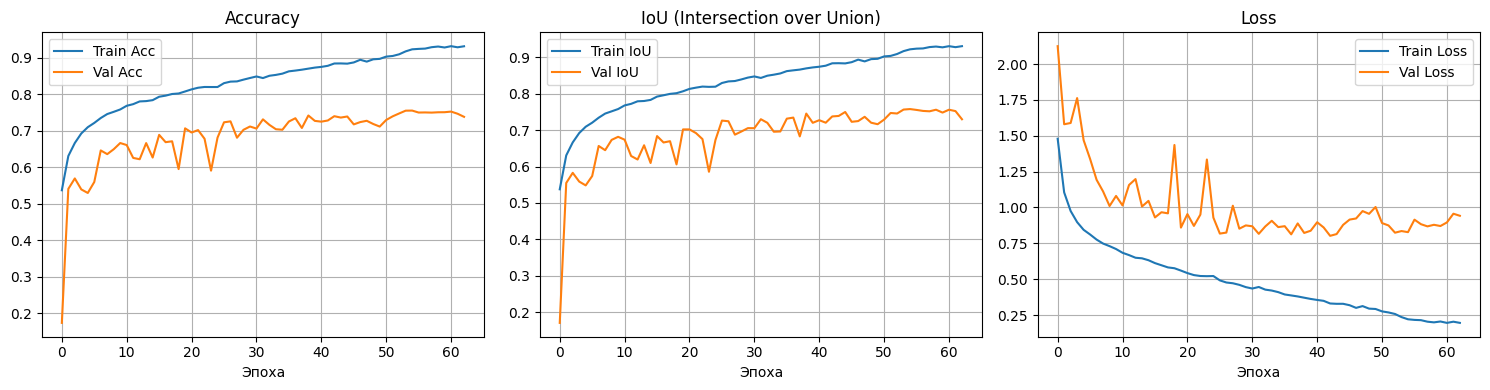


Финальные результаты:
Val Accuracy: 0.7380
Val IoU: 0.7300


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['iou_coef'], label='Train IoU')
axes[1].plot(history.history['val_iou_coef'], label='Val IoU')
axes[1].set_title('IoU (Intersection over Union)')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['loss'], label='Train Loss')
axes[2].plot(history.history['val_loss'], label='Val Loss')
axes[2].set_title('Loss')
axes[2].set_xlabel('Эпоха')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"\nФинальные результаты:")
print(f"Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Val IoU: {history.history['val_iou_coef'][-1]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


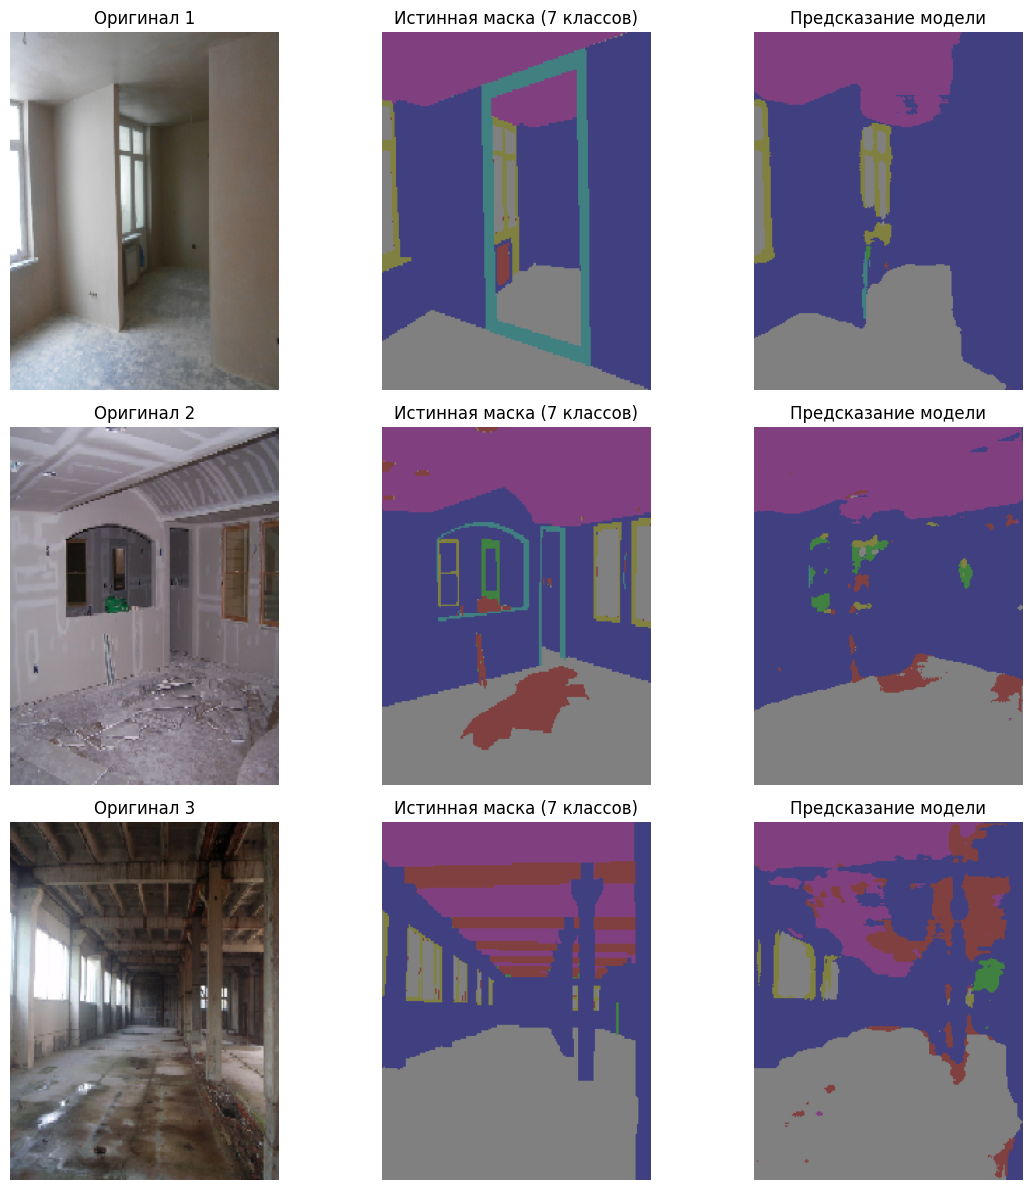

  Пример 1: IoU = 0.8782
  Пример 2: IoU = 0.8139
  Пример 3: IoU = 0.7648


In [ ]:
def mask_to_rgb(mask, colors):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype='uint8')
    for i, color in enumerate(colors):
        rgb[mask == i] = color
    return rgb

num_samples = 3
predictions = model.predict(x_val[:num_samples])
pred_masks = np.argmax(predictions, axis=-1)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

for i in range(num_samples):
    axes[i, 0].imshow(x_val[i])
    axes[i, 0].set_title(f'Оригинал {i+1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_to_rgb(y_val[i], CLASS_COLORS_7))
    axes[i, 1].set_title(f'Истинная маска (7 классов)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mask_to_rgb(pred_masks[i], CLASS_COLORS_7))
    axes[i, 2].set_title(f'Предсказание модели')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

for i in range(num_samples):
    intersection = np.sum((y_val[i] == pred_masks[i]) & (y_val[i] != 0))
    union = np.sum((y_val[i] != 0) | (pred_masks[i] != 0))
    iou = intersection / union if union > 0 else 0
    print(f"  Пример {i+1}: IoU = {iou:.4f}")